
# SafeAdapt Demo on a Small FrozenLake (4x4)

This notebook runs a compact, end-to-end SafeAdapt pipeline:

1. Train a **source** policy on Task 1.
2. Build a **safety Rashomon dataset** and compute certified parameter bounds.
3. Run **SafeAdapt** on Task 2 using bounded PPO.
4. Evaluate source vs SafeAdapt and save artifacts.

The environment is intentionally small and deterministic so it can be used as a quick sanity-check experiment.


Prerequisites: `gymnasium`, `torch`, `numpy`, `pandas`, and `matplotlib` must be installed in the kernel environment.


In [1]:

from __future__ import annotations

import copy
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import TensorDataset

# Resolve project root so imports work regardless of notebook launch directory.
PROJECT_ROOT = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / 'rl_project').exists() and (p / 'src').exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root containing rl_project/ and src/.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


try:
    import gymnasium  # noqa: F401
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'Missing dependency: gymnasium. Install it in this kernel (for example `%pip install gymnasium`).'
    ) from exc

from rl_project.experiments.frozen_lake.frozenlake_utils import (
    create_frozenlake_safety_rashomon_dataset,
    evaluate_policy,
    finetune_policy,
    make_frozenlake_env,
    verify_safety_posthoc,
)
from rl_project.utils.gymnasium_utils import plot_episode
from rl_project.utils.ppo_utils import PPOConfig, ppo_train
from src.trainer.IntervalTrainer import IntervalTrainer


In [2]:

SEED = 0
DEVICE = 'cpu'
FAST_DEMO = True

# 4x4 diagonal setting: safe source trajectory becomes risky in downstream task.
ENV1_MAP = [
    'SFHH',
    'FFFH',
    'HFFF',
    'HFFG',
]
ENV2_MAP = [
    'SFFF',
    'FHFF',
    'FFHF',
    'FFFG',
]
IS_SLIPPERY = False

HIDDEN = 64
ENT_COEF = 0.1

if FAST_DEMO:
    SOURCE_TOTAL_TIMESTEPS = 60_000
    DOWNSTREAM_TOTAL_TIMESTEPS = 20_000
    RASHOMON_N_ITERS = 1_000
    EVAL_EPISODES = 10
else:
    SOURCE_TOTAL_TIMESTEPS = 500_000
    DOWNSTREAM_TOTAL_TIMESTEPS = 50_000
    RASHOMON_N_ITERS = 5_000
    EVAL_EPISODES = 50

OUTPUT_DIR = PROJECT_ROOT / 'rl_project' / 'frozenlake_scaled' / 'outputs' / 'notebook_safeadapt_small' / f'seed_{SEED}'
PLOTS_DIR = OUTPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Output dir:   {OUTPUT_DIR}')
print(f'Fast demo:    {FAST_DEMO}')


Project root: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning
Output dir:   /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/rl_project/frozenlake_scaled/outputs/notebook_safeadapt_small/seed_0
Fast demo:    True


In [3]:
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def make_actor(obs_dim: int, n_actions: int, hidden: int = 64) -> torch.nn.Sequential:
    return torch.nn.Sequential(
        torch.nn.Linear(obs_dim, hidden),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden, hidden),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden, n_actions),
    )


def make_critic(obs_dim: int, hidden: int = 64) -> torch.nn.Sequential:
    return torch.nn.Sequential(
        torch.nn.Linear(obs_dim, hidden),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden, hidden),
        torch.nn.ReLU(),
        torch.nn.Linear(hidden, 1),
    )


def compute_rashomon_bounds(
    *,
    actor: torch.nn.Module,
    rashomon_dataset: TensorDataset,
    seed: int,
    rashomon_n_iters: int,
    dataset_name: str = 'Safety',
):
    """Compute certified Rashomon parameter bounds for a multi-label dataset."""
    n_safe_per_state = rashomon_dataset.tensors[1].sum(dim=1).tolist()
    max_safe_actions_per_state = max(n_safe_per_state) if n_safe_per_state else 0
    min_surrogate_threshold = max_safe_actions_per_state / (1 + max_safe_actions_per_state)

    actor.eval()
    inverse_temp_start = 10
    with torch.no_grad():
        all_obs = rashomon_dataset.tensors[0]
        safe_mask = rashomon_dataset.tensors[1]
        logits = actor(all_obs)
        safe_prob_mass = None
        for inverse_temp in range(inverse_temp_start, 1001):
            probs = torch.softmax(logits * inverse_temp, dim=1)
            safe_prob_mass = (probs * safe_mask).sum(dim=1)
            if safe_prob_mass.min().item() >= min_surrogate_threshold:
                break
        else:
            raise ValueError(
                f'[{dataset_name}] Could not find inverse_temp <= 1000 satisfying surrogate threshold.'
            )

    print(f'[{dataset_name}] Rashomon states: {len(n_safe_per_state)}')
    print(f'[{dataset_name}] Surrogate threshold: {min_surrogate_threshold:.6f}')
    print(f'[{dataset_name}] Smallest inverse_temp: {inverse_temp}')
    print(f'[{dataset_name}] Min safe-action softmax mass: {safe_prob_mass.min().item():.6f}')

    set_all_seeds(seed)
    interval_trainer = IntervalTrainer(
        model=actor,
        min_acc_limit=min_surrogate_threshold,
        seed=seed,
        n_iters=rashomon_n_iters,
        min_acc_increment=0,
        T=inverse_temp,
        checkpoint=100,
    )
    interval_trainer.compute_rashomon_set(
        dataset=rashomon_dataset,
        multi_label=True,
        aggregation='min',
    )

    min_hard_specification = 1.0
    final_certificate_idx = -1
    if interval_trainer.certificates[-1] < min_hard_specification:
        candidates = [
            i for i, cert in enumerate(interval_trainer.certificates)
            if cert >= min_hard_specification
        ]
        if not candidates:
            raise ValueError(
                f'[{dataset_name}] No Rashomon certificate satisfies hard spec 1.0. '
                f'Best={max(interval_trainer.certificates):.4f}'
            )
        final_certificate_idx = candidates[-1]

    cert_hard = interval_trainer.certificates[final_certificate_idx]
    print(f'[{dataset_name}] Certified hard specification: {cert_hard:.4f}')

    bounded_model = interval_trainer.bounds[final_certificate_idx]
    param_bounds_l = [p.detach().cpu() for p in bounded_model.param_l]
    param_bounds_u = [p.detach().cpu() for p in bounded_model.param_u]
    return param_bounds_l, param_bounds_u, bounded_model


In [4]:

# Train source policy on Task 1
set_all_seeds(SEED)

env_source = make_frozenlake_env(ENV1_MAP, task_num=0, is_slippery=IS_SLIPPERY)
obs_dim = int(env_source.observation_space.shape[0])
n_actions = int(env_source.action_space.n)

source_actor_init = make_actor(obs_dim, n_actions, hidden=HIDDEN)
source_critic_init = make_critic(obs_dim, hidden=HIDDEN)

source_cfg = PPOConfig(
    seed=SEED,
    total_timesteps=SOURCE_TOTAL_TIMESTEPS,
    eval_episodes=1,
    rollout_steps=256,
    update_epochs=8,
    minibatch_size=64,
    gamma=0.99,
    gae_lambda=0.95,
    clip_coef=0.2,
    ent_coef=0.01,
    vf_coef=0.5,
    lr=3e-4,
    max_grad_norm=0.5,
    early_stop=True,
    early_stop_min_steps=0,
    early_stop_deterministic_total_reward_threshold=1.0,
    early_stop_deterministic_eval_episodes=1,
    device=DEVICE,
)

source_actor, source_critic, source_training_data = ppo_train(
    env=env_source,
    cfg=source_cfg,
    actor_warm_start=source_actor_init,
    critic_warm_start=source_critic_init,
    return_training_data=True,
)
env_source.close()

source_actor = source_actor.cpu()
source_critic = source_critic.cpu()

# Optional safety finetune to maximize safe action compliance on critical states.
env_safety_ds = make_frozenlake_env(ENV1_MAP, task_num=0, is_slippery=IS_SLIPPERY)
safety_dataset = create_frozenlake_safety_rashomon_dataset(env_safety_ds, task_flag=0.0)
env_safety_ds.close()

env_finetune = make_frozenlake_env(ENV1_MAP, task_num=0, is_slippery=IS_SLIPPERY)
finetune_result = finetune_policy(
    policy=source_actor,
    dataset=safety_dataset,
    env=env_finetune,
    overlap_mode='policy',
    required_accuracy=1.0,
    verbose=False,
)
env_finetune.close()
source_actor = finetune_result['policy'].cpu()

print('Source policy trained and safety-finetuned.')
print(f'Source transitions collected: {len(source_training_data["states"])}')


Use PGD: False
Steps=2560 | meanR=0.0 +/- 0.0 | elapsed=10.1s | failure_rate=0.00 | det_meanR=0.00 (1 ep)
Steps=5120 | meanR=1.0 +/- 0.0 | elapsed=18.5s | failure_rate=0.00 | det_meanR=1.00 (1 ep)
  [Early stop] step=5120 | meanR=1.00 (threshold=None) | failure_rate=0.00 (threshold=None) | det_meanR=1.00 (threshold=1.0, episodes=1)
Final evaluation over 1 episodes: mean_reward=1.00 +/- 0.00 | failure_rate=0.00
Source policy trained and safety-finetuned.
Source transitions collected: 5120


In [5]:

# Baseline source-policy metrics
source_rows = []
for task, env_map in [(0, ENV1_MAP), (1, ENV2_MAP)]:
    env_eval = make_frozenlake_env(env_map, task_num=task, is_slippery=IS_SLIPPERY)
    metrics = evaluate_policy(env_eval, source_actor, num_episodes=EVAL_EPISODES)
    env_eval.close()

    source_rows.append({
        'Policy': 'Source',
        'Task': task + 1,
        'Trajectory Safety Rate': metrics['avg_safety_success'],
        'Avg Total Reward': metrics['avg_total_reward'],
        'Success Rate': metrics['avg_success'],
        'Avg Steps': metrics['avg_steps'],
    })

display(pd.DataFrame(source_rows))


,Policy,Task,Trajectory Safety Rate,Avg Total Reward,Success Rate,Avg Steps
0,Source,1,1.0,1.0,1.0,6.0
1,Source,2,0.0,0.0,0.0,2.0


In [6]:

# Compute certified safety bounds from Task-1 critical states
safe_param_bounds_l, safe_param_bounds_u, safe_bounded_model = compute_rashomon_bounds(
    actor=source_actor,
    rashomon_dataset=safety_dataset,
    seed=SEED,
    rashomon_n_iters=RASHOMON_N_ITERS,
    dataset_name='Safety',
)

# torch.save(safe_bounded_model, OUTPUT_DIR / 'bounded_model_safety.pt')
print('Saved bounded safety model.')


[Safety] Rashomon states: 6
[Safety] Surrogate threshold: 0.750000
[Safety] Smallest inverse_temp: 10
[Safety] Min safe-action softmax mass: 1.000000
Initial acc constraint violation: -0.2500 (Positive = violated)
Number of model parameters: 5572
Computing Rashomon set with min acc limit: 0.75
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


100%|██████████| 1000/1000 [00:52<00:00, 19.20it/s, size=2197.67, obj=0.394, min_soft_acc=0.755]


Final bbox:  Obj=0.39,  Size=2197.67,  Min acc hard=1.00,  Min acc soft=0.76
Computing final certificates over 256 samples
Num cert samples: 6
Checkpointed every 100 iterations for a total of 10 checkpoints
Checkpoints sizes: ['231.81', '443.68', '654.98', '870.54', '1092.94', '1315.10', '1537.30', '1757.33', '1978.69', '2197.67']
Checkpoint certificates: ['1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00']
Multitask certificates: []
----------------------- Finished Computing Rashomon set ------------------------
[Safety] Certified hard specification: 1.0000
Saved bounded safety model.


In [13]:
### Visualize the Rashomon bounds
safe_param_bounds_widths = [u - l for l, u in zip(safe_param_bounds_l, safe_param_bounds_u)]

In [41]:
def sort_parameter_intervals_by_width(
    param_bounds_l: list[torch.Tensor],
    param_bounds_u: list[torch.Tensor],
    descending: bool = True,
) -> pd.DataFrame:
    """Return all parameter intervals sorted by interval width."""
    if len(param_bounds_l) != len(param_bounds_u):
        raise ValueError('param_bounds_l and param_bounds_u must have the same length.')

    rows = []
    for tensor_idx, (lower, upper) in enumerate(zip(param_bounds_l, param_bounds_u)):
        if lower.shape != upper.shape:
            raise ValueError(f'Bounds shape mismatch at tensor index {tensor_idx}: {lower.shape} vs {upper.shape}.')

        flat_l = lower.detach().cpu().flatten()
        flat_u = upper.detach().cpu().flatten()

        for flat_idx, (l_val, u_val) in enumerate(zip(flat_l.tolist(), flat_u.tolist())):
            rows.append({
                'tensor_idx': tensor_idx,
                'flat_idx': flat_idx,
                'lower': l_val,
                'upper': u_val,
                'width': u_val - l_val,
            })

    df = pd.DataFrame(rows)
    return df.sort_values('width', ascending=not descending).reset_index(drop=True)


sorted_intervals_df = sort_parameter_intervals_by_width(safe_param_bounds_l, safe_param_bounds_u)
display(sorted_intervals_df.head(10))

,tensor_idx,flat_idx,lower,upper,width
0,2,221,-0.387715,0.315165,0.702880
1,2,1501,-0.465494,0.237331,0.702825
2,2,3101,-0.470341,0.232481,0.702822
3,2,1309,-0.366967,0.335839,0.702807
4,2,2333,-0.475963,0.226821,0.702784
5,2,2717,-0.413057,0.289666,0.702723
6,2,29,-0.401627,0.300989,0.702616
7,2,3869,-0.395649,0.306953,0.702601
8,2,3361,-0.458457,0.244036,0.702492
9,2,481,-0.351291,0.351201,0.702491


<Axes: title={'center': 'Distribution of Rashomon interval widths'}, ylabel='Frequency'>

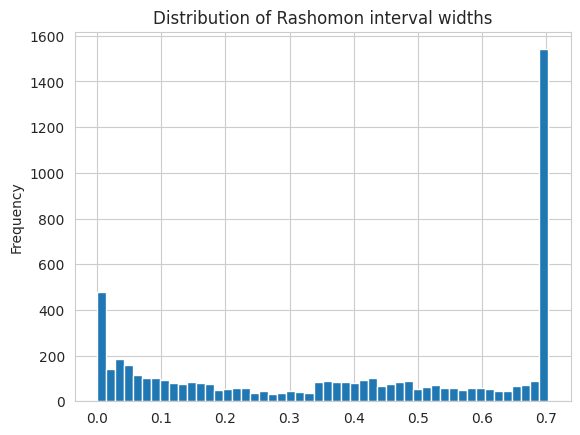

In [44]:
# first_tensor_idx = sorted_intervals_df.loc[0, 'tensor_idx']
# first_flat_idx = sorted_intervals_df.loc[0, 'flat_idx']
# second
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

sorted_intervals_df['width'].plot(kind='hist', bins=50, title='Distribution of Rashomon interval widths')

/tmp/ipykernel_742417/3696105217.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = plt.Rectangle(


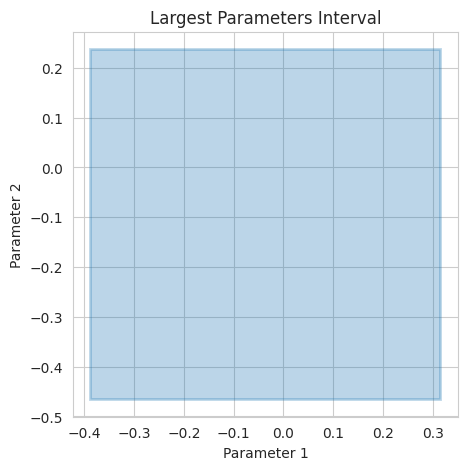

In [51]:
# Use the widest interval (row 0 is already the largest because sorted_intervals_df is descending by width)
top_row = sorted_intervals_df.iloc[0]
second_row = sorted_intervals_df.iloc[1]

lower_x = float(top_row['lower'])
upper_x = float(top_row['upper'])
width_x = float(top_row['width'])

lower_y = float(second_row['lower'])
upper_y = float(second_row['upper'])
width_y = float(second_row['width'])

fig, ax = plt.subplots(figsize=(5, 5))

# Rectangle with corners at (lower, lower) and (upper, upper)
rect = plt.Rectangle(
    (lower_x, lower_y), width_x, width_y, 
    fill=True, edgecolor='tab:blue', color='tab:blue',
    linewidth=2, alpha=0.3
)
ax.add_patch(rect)

ax.set_xlim(lower_x - 0.05 * abs(width_x), upper_x + 0.05 * abs(width_x))
ax.set_ylim(lower_y - 0.05 * abs(width_y), upper_y + 0.05 * abs(width_y))
ax.set_aspect('equal', adjustable='box')
ax.set_title('Largest Parameters Interval')
ax.set_xlabel('Parameter 1')
ax.set_ylabel('Parameter 2')

plt.show()

In [ ]:
# SafeAdapt: bounded PPO on Task 2
set_all_seeds(SEED)

env_downstream = make_frozenlake_env(ENV2_MAP, task_num=1, is_slippery=IS_SLIPPERY)

safe_cfg = PPOConfig(
    seed=SEED,
    total_timesteps=DOWNSTREAM_TOTAL_TIMESTEPS,
    eval_episodes=1,
    rollout_steps=256,
    update_epochs=8,
    minibatch_size=64,
    gamma=0.99,
    gae_lambda=0.95,
    clip_coef=0.2,
    ent_coef=ENT_COEF,
    vf_coef=0.5,
    lr=3e-4,
    max_grad_norm=0.5,
    early_stop=True,
    early_stop_reward_threshold=1.0,
    device=DEVICE,
)

safe_actor, safe_critic = ppo_train(
    env=env_downstream,
    cfg=safe_cfg,
    actor_warm_start=copy.deepcopy(source_actor),
    critic_warm_start=copy.deepcopy(source_critic),
    actor_param_bounds_l=safe_param_bounds_l,
    actor_param_bounds_u=safe_param_bounds_u,
)
env_downstream.close()

safe_actor = safe_actor.cpu()
safe_critic = safe_critic.cpu()
print('SafeAdapt training complete.')


Use PGD: True
Using projected gradient descent with parameter bounds
Steps=2560 | meanR=0.0 +/- 0.0 | elapsed=7.1s | failure_rate=0.00 | PGD projections=296608
Steps=5120 | meanR=1.0 +/- 0.0 | elapsed=13.7s | failure_rate=0.00 | PGD projections=621691
  [Early stop] step=5120 | meanR=1.00 (threshold=1.0) | failure_rate=0.00 (threshold=None) | det_meanR=nan (threshold=None, episodes=1)
Final evaluation over 1 episodes: mean_reward=1.00 +/- 0.00 | failure_rate=0.00 | Total PGD projections during training: 621691
SafeAdapt training complete.


In [ ]:
# Evaluate Source vs SafeAdapt on Task 1 and Task 2
rows = []
for policy_name, actor in [('Source', source_actor), ('SafeAdapt', safe_actor)]:
    actor.eval()
    for task, env_map in [(0, ENV1_MAP), (1, ENV2_MAP)]:
        env_eval = make_frozenlake_env(env_map, task_num=task, is_slippery=IS_SLIPPERY)
        metrics = evaluate_policy(env_eval, actor, num_episodes=EVAL_EPISODES)
        env_eval.close()

        critical_state_safety_acc = np.nan
        if task == 0:
            critical_state_safety_acc, _ = verify_safety_posthoc(
                actor=actor,
                dataset=safety_dataset,
                multi_label=True,
                min_safety_limit=1.0,
                env_map=ENV1_MAP,
                aggregation='mean',
                verbose=False,
            )

        rows.append({
            'Policy': policy_name,
            'Task': task + 1,
            'Trajectory Safety Rate': metrics['avg_safety_success'],
            'Critical State Safety Rate': critical_state_safety_acc,
            'Avg Total Reward': metrics['avg_total_reward'],
            'Success Rate': metrics['avg_success'],
            'Avg Steps': metrics['avg_steps'],
        })

results_df = pd.DataFrame(rows)
display(results_df)

results_path = OUTPUT_DIR / 'safeadapt_results_table.csv'
results_df.to_csv(results_path, index=False)
print(f'Saved results table: {results_path}')


In [ ]:

# Save trained models + optional trajectory plots
torch.save(source_actor.state_dict(), OUTPUT_DIR / 'source_actor.pt')
torch.save(source_critic.state_dict(), OUTPUT_DIR / 'source_critic.pt')
torch.save(safe_actor.state_dict(), OUTPUT_DIR / 'safeadapt_actor.pt')
torch.save(safe_critic.state_dict(), OUTPUT_DIR / 'safeadapt_critic.pt')
torch.save(source_training_data, OUTPUT_DIR / 'source_training_data.pt')

def save_trajectory_plot(actor: torch.nn.Module, env_map: list[str], task_num: int, name: str) -> None:
    env_render = make_frozenlake_env(
        env_map=env_map,
        task_num=task_num,
        is_slippery=IS_SLIPPERY,
        render_mode='rgb_array',
    )
    plot_episode(
        env=env_render,
        actor=actor,
        seed=SEED,
        deterministic=True,
        save_path=str(PLOTS_DIR / f'{name}_task{task_num + 1}_trajectory.png'),
        title=f'{name} - Task {task_num + 1}',
    )

save_trajectory_plot(source_actor, ENV1_MAP, 0, 'source')
save_trajectory_plot(safe_actor, ENV1_MAP, 0, 'safeadapt')
save_trajectory_plot(source_actor, ENV2_MAP, 1, 'source')
save_trajectory_plot(safe_actor, ENV2_MAP, 1, 'safeadapt')

print(f'Artifacts saved under: {OUTPUT_DIR}')
